# Ropedia Academy — D1 · Dense SLAM: the core paradox

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/D1.ipynb)

> **Simulates the SLAM paradox and plots the drifting odometry trajectory against the loop-closure-corrected one snapping the loop shut.**
>
> 模拟 SLAM 悖论，并画出漂移的里程计轨迹与回环校正后闭合的轨迹对比。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/D1

drift at loop end: 0.135 -> after loop closure: 0.0


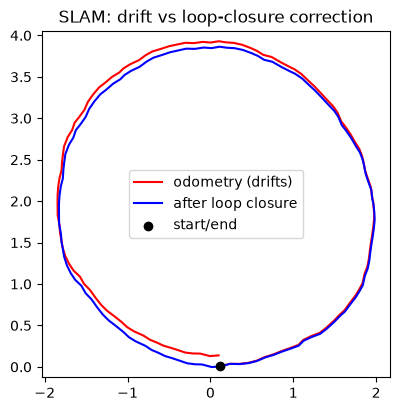

In [1]:
import numpy as np, matplotlib.pyplot as plt
# SLAM: odometry drifts; loop closure redistributes the error.

# ---------- INPUT: a closed-loop path with noisy per-step motion ----------
np.random.seed(0); N = 120
true_steps = np.column_stack([np.cos(np.linspace(0,2*np.pi,N)),
                              np.sin(np.linspace(0,2*np.pi,N))]) * 0.1

# ---------- MODEL: integrate (front-end) then close the loop (back-end) ----------
odom = np.cumsum(true_steps + np.random.randn(N,2)*0.012, 0)
corrected = odom - np.linspace(0,1,N)[:,None] * (odom[-1]-odom[0])

# ---------- OUTPUT: drift before/after + the two trajectories ----------
print("drift at loop end:", round(np.linalg.norm(odom[-1]-odom[0]), 3),
      "-> after loop closure:", round(np.linalg.norm(corrected[-1]-corrected[0]), 3))
plt.figure(figsize=(4.5, 4.5))
plt.plot(odom[:,0], odom[:,1], 'r-', label='odometry (drifts)')
plt.plot(corrected[:,0], corrected[:,1], 'b-', label='after loop closure')
plt.scatter(*odom[0], c='k', zorder=3, label='start/end')
plt.axis('equal'); plt.legend(); plt.title("SLAM: drift vs loop-closure correction"); plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/D1
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks